# 07 — Intervention What-If and Cost Impact

This notebook is a deterministic counterfactual replay: we run the same one-day scenario twice and compare the traces side-by-side.

- Baseline: natural washing-machine schedule
- Intervention: washing machine delayed by 2 hours

We overlay real SMARD DE-LU prices and compute a simple cost delta from 15-minute slots to quantify the effect.

This is an evaluation demo, not an optimization run. No schedule search is performed here; the intervention is manually specified and then measured.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from datetime import datetime, timedelta, timezone

import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

from aerogrid.config import SCENARIO_TEST_START
from aerogrid.sim.scenario import (
    ScenarioGenerator, default_scenario_spec,
)

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic('matplotlib', 'widget')
    except Exception:
        pass
from aerogrid.price_oracle import load_price_history

gen = ScenarioGenerator()
# One-day spec centred on the test window.
start = SCENARIO_TEST_START + timedelta(days=1)
end = start + timedelta(days=1)
spec = default_scenario_spec(start, end, seed=7)

baseline = gen.generate(spec)
intervened_spec = gen.apply_intervention_delay(spec, 'washing_machine', timedelta(hours=2))
intervened = gen.generate(intervened_spec)

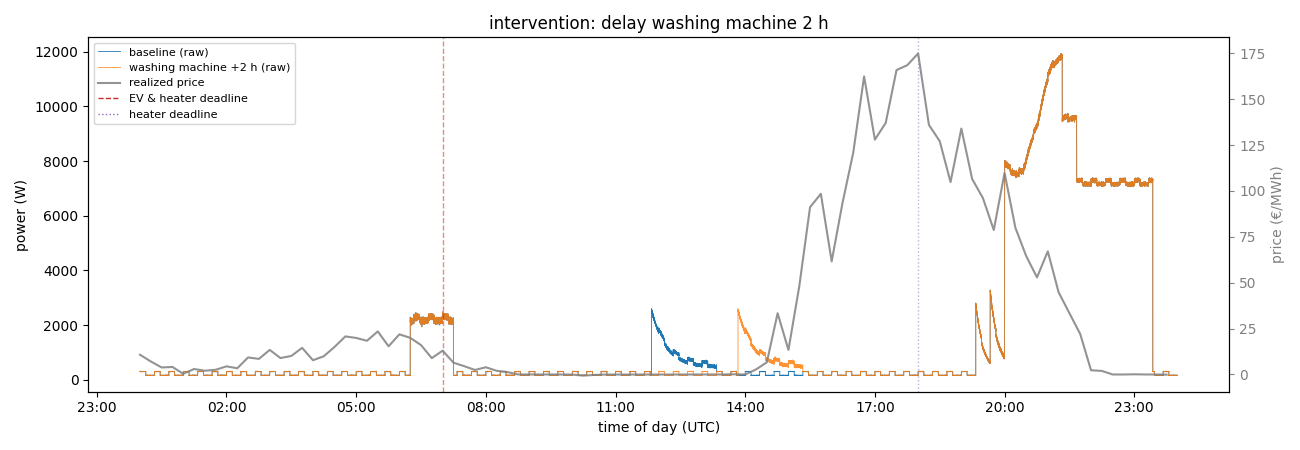

In [2]:
# Plot: baseline vs intervened aggregate, with realized prices on a twin axis.
# - X-axis: wall-clock time of day (HH:MM) — easier to read than relative
#   "+1 h, +2 h" offsets, especially when comparing against deadlines.
# - Vertical lines mark the EV deadline (07:00) and heater deadlines
#   (07:00 and 18:00) so the schedule context is visible at a glance.
# - All series at their original sampling cadence (no resampling).
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

from aerogrid.config import EV_DEADLINE_HOUR, HEATER_DEADLINES

try:
    prices = load_price_history()
    day_px = prices[(prices['timestamp'] >= start) & (prices['timestamp'] < end)].sort_values('timestamp')
except FileNotFoundError:
    day_px = None
    print('No SMARD parquet — run scripts/fetch_smard_prices.py for the price overlay.')

baseline_raw = baseline.mains.sort_values('timestamp')
intervened_raw = intervened.mains.sort_values('timestamp')

fig, ax = plt.subplots(figsize=(13, 4.5))
line_base, = ax.plot(
    baseline_raw['timestamp'], baseline_raw['power_w'],
    lw=0.6, color='C0', label='baseline (raw)',
)
line_intv, = ax.plot(
    intervened_raw['timestamp'], intervened_raw['power_w'],
    lw=0.6, color='C1', alpha=0.85, label='washing machine +2 h (raw)',
)
ax.set_ylabel('power (W)')
ax.set_xlabel('time of day (UTC)')
ax.set_title('intervention: delay washing machine 2 h')

# HH:MM x-axis (24 h window).
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Deadline lines: EV (07:00) red dashed, heater (07:00 & 18:00) purple dotted.
deadline_hours = sorted({EV_DEADLINE_HOUR} | {d.hour for d in HEATER_DEADLINES})
deadline_legend = {}
for day in pd.date_range(
    pd.Timestamp(start).floor('D'), pd.Timestamp(end).ceil('D'),
    freq='D', tz='UTC',
):
    for hour in deadline_hours:
        t_d = day.replace(hour=hour, minute=0, second=0, microsecond=0)
        if not (start <= t_d <= end):
            continue
        is_ev = (hour == EV_DEADLINE_HOUR)
        is_heater = any(d.hour == hour for d in HEATER_DEADLINES)
        if is_ev and is_heater:
            color, ls, label = '#d62728', '--', 'EV & heater deadline'
        elif is_ev:
            color, ls, label = '#d62728', '--', 'EV deadline'
        else:
            color, ls, label = '#9467bd', ':', 'heater deadline'
        ax.axvline(t_d, color=color, ls=ls, lw=1.0, alpha=0.55)
        deadline_legend.setdefault(label, (color, ls))

legend_handles = [line_base, line_intv]

if day_px is not None and not day_px.empty:
    axp = ax.twinx()
    line_px, = axp.plot(
        day_px['timestamp'], day_px['lbmp'],
        color='grey', alpha=0.85, lw=1.5, label='realized price',
    )
    axp.set_ylabel('price (€/MWh)', color='grey')
    axp.tick_params(axis='y', colors='grey')
    legend_handles.append(line_px)

# Add deadline lines to the legend.
for label, (color, ls) in deadline_legend.items():
    legend_handles.append(Line2D([0], [0], color=color, ls=ls, lw=1.0, label=label))

ax.legend(handles=legend_handles, loc='upper left', fontsize=8)
fig.autofmt_xdate(rotation=0, ha='center')
plt.tight_layout()
plt.show()


In [3]:
# Cost comparison: integrate each scenario's aggregate against the 15-min LBMP.
if day_px is not None and not day_px.empty:
    def integrate(mains_df, px_df):
        # Sum power × price per 15-min slot.
        mains = mains_df.copy()
        mains['slot'] = mains['timestamp'].dt.floor('15min')
        per_slot_w = mains.groupby('slot')['power_w'].mean().reset_index()
        merged = per_slot_w.merge(px_df.rename(columns={'timestamp': 'slot'}), on='slot', how='inner')
        # kW × $/MWh × h / 1000 → $
        cost = (merged['power_w'] / 1000.0 * merged['lbmp'] * 0.25 / 1000.0).sum()
        return float(cost)

    c_base = integrate(baseline.mains, day_px)
    c_int = integrate(intervened.mains, day_px)
    print(f'baseline    cost: ${c_base:.3f}')
    print(f'intervened  cost: ${c_int:.3f}')
    print(f'delta:           ${c_int - c_base:+.3f}  ({(c_int - c_base) / c_base * 100:+.1f}%)')

baseline    cost: $1.320
intervened  cost: $1.327
delta:           $+0.007  (+0.5%)
